In [1]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
import subprocess
from tqdm import tqdm_notebook
import pprint
import librosa
from IPython.display import clear_output
from scipy.ndimage import convolve
import music21
import madmom
from scipy.signal import convolve2d
from scipy.stats import linregress
import yaml

from msmd.midi_parser import notes_to_onsets, FPS
from msmd.data_model.piece import Piece
from msmd.alignments import align_score_to_performance

In [2]:
# path to MSMD dataset
DATA_ROOT_MSMD = '/data/mirlab/msmd/msmd_aug/msmd_aug'

In [3]:
# obtain all the pieces in the dataset
with open('/data/mirlab/msmd/msmd/msmd/splits/all_pieces.yaml', 'r') as f:
    doc = yaml.load(f)
    
pieces = doc['success']

In [4]:
def extractStrips(mungos_per_page):
    """
    Extract a list of staves' mungos objects.
    
    Input: 
        mungos_per_page - a list of mungos per page
        
    Output:
        strips - a list of (page, system_mungo, notehead_mungos) indicating each strip in sequential order.
        where 
            page = page number
            system_mungo = a mungo for a staff
            notehead_mungos = mungos for all noteheads in that page
    """
    strips = []
    
    page_num = len(mungos_per_page)
    for page in range(page_num):
        system_mungos = [c for c in mungos_per_page[page] if c.clsname == 'staff']
        system_mungos = sorted(system_mungos, key=lambda m: m.top)
        notehead_mungos = [c for c in mungos_per_page[page] if c.clsname == 'notehead-full']
        for system_mungo in system_mungos:
            strips.append((page, system_mungo, notehead_mungos))
    
    return strips

In [12]:
def convertMungoToImage(system_mungo, notehead_mungos, image, page_num,
                        marginLeftRatio=0,
                        marginRightRatio=0,
                        marginTopRatio=0.45, 
                        marginBottomRatio=0.45,
                        verbose=True):
    """
    Convert staff location information from mungo to an actual image.
    
    Input:
        system_mungo - mungo for a staff line
        notehead_mungos - mungos for noteheads
        image - an image of the page corresponding to the system_mungo
        
    Output:
        image - an image in np.array whose values are np.int8
    
    """
    
    # Get the bounding box of the staff
    (y_top, x_left, y_bottom, x_right) = system_mungo.bounding_box
    height = y_bottom - y_top
    width = x_right - x_left
    
    # Calculate the vertical margins
    marginTop = min(int(round(marginTopRatio * height)), y_top)  #  Prevent out-of-page margin
    marginBottom = min(int(round(marginBottomRatio * height)), image.shape[0] - y_bottom) #  Prevent out-of-page margin
     
    # Calculate the starting and ending vertical positions
    y_start = y_top - marginTop
    y_end = y_bottom + marginBottom
    
    # Calculate the horizontal margins
    marginLeft = min(int(round(marginLeftRatio * width)), x_left) # Prevent out-of-page margin
    marginRight = min(int(round(marginRightRatio * width)), image.shape[1] - x_right) # Prevent out-of-page margin
    
    # Calculate the starting and ending horizontal positions
    x_start = x_left - marginLeft
    x_end = x_right + marginRight
    
    # Plot noteheads
    out_mungos = {}
    for n in notehead_mungos:
        if x_start <= n.middle[1] < x_end and y_start <= n.middle[0] < y_end:
            # Add notes to the output list
            n.translate(down=-y_start, right=-x_start)
            out_mungos[n.objid] = n
            if verbose:
                plt.plot(n.middle[1] - x_start, n.middle[0] - y_start, 'bo', alpha=0.5)
    
    if verbose:
        plt.imshow(image[y_start:y_end,x_start:x_end], cmap="gray")
        plt.show()
        
    return image[y_start:y_end, x_start:x_end], out_mungos

In [127]:
def calcErrorStats(errs, tols):
    errorRates = []
    for tol in tols:
        toAdd = np.sum(np.abs(errs) >= tol) / len(errs)
        errorRates.append(toAdd)
        
    avgError = np.average(np.abs(errs))
    stdError = np.std(np.abs(errs))
    return errorRates, avgError, stdError

gt_x = 75    spec_x = 0    resclaed_spec_x = 50   pred_x = 51.5 err = -23.5
gt_x = 75    spec_x = 0    resclaed_spec_x = 50   pred_x = 51.5 err = -23.5
gt_x = 99    spec_x = 10    resclaed_spec_x = 90   pred_x = 103.0 err = 4.0
gt_x = 99    spec_x = 10    resclaed_spec_x = 90   pred_x = 103.0 err = 4.0
gt_x = 116    spec_x = 15    resclaed_spec_x = 110   pred_x = 119.0 err = 3.0
gt_x = 128    spec_x = 19    resclaed_spec_x = 126   pred_x = 139.0 err = 11.0
gt_x = 144    spec_x = 20    resclaed_spec_x = 130   pred_x = 146.0 err = 2.0
gt_x = 144    spec_x = 20    resclaed_spec_x = 130   pred_x = 146.0 err = 2.0
gt_x = 167    spec_x = 30    resclaed_spec_x = 170   pred_x = 171.0 err = 4.0
gt_x = 167    spec_x = 30    resclaed_spec_x = 170   pred_x = 171.0 err = 4.0
gt_x = 184    spec_x = 35    resclaed_spec_x = 190   pred_x = 187.0 err = 3.0
gt_x = 200    spec_x = 40    resclaed_spec_x = 210   pred_x = 206.0 err = 6.0
gt_x = 200    spec_x = 40    resclaed_spec_x = 210   pred_x = 206.0 err

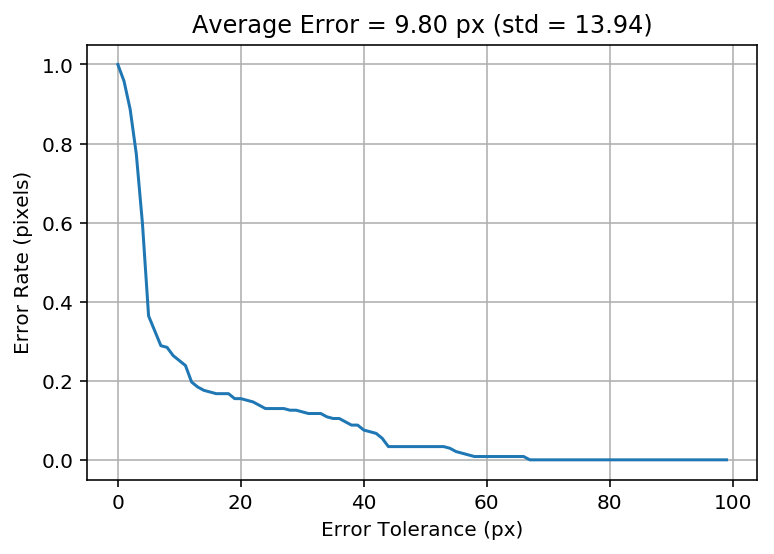

In [129]:
# for piece_name in tqdm_notebook(pieces):
for piece_name in ['BachJS__BWVAnh117b__BWV-117b']:
    # Load the piece and score
    piece = Piece(root=DATA_ROOT_MSMD, name=piece_name)
    assert len(piece.available_scores) == 1
    score = piece.load_score(piece.available_scores[0])
    images = score.load_images()
    
    # Get mungos
    mungos = score.load_mungos()
    mdict = {m.objid: m for m in mungos}
    mungos_per_page = score.load_mungos(by_page=True)
    
    # Extract strips
    strips = extractStrips(mungos_per_page)
    strip_images = []
    note_mango_dict = {}
    for (strip_num, (page, system_mungo, note_mungos)) in enumerate(strips):
        strip_image, out_mungos = convertMungoToImage(system_mungo, 
                                                      note_mungos, 
                                                      images[page], 
                                                      page,
                                                      verbose=False)
        strip_images.append(strip_image)
        for n in out_mungos:
            note_mango_dict[n] = (strip_num, out_mungos[n])
    
    # Compute base x refs
    base_x_strips = [0]
    for strip_num in range(1,len(strip_images)):
        base_x_strips.append(base_x_strips[strip_num - 1] + strip_images[strip_num - 1].shape[1])
    
    # Enumerate over all performances
    for performance_name in piece.available_performances:        
        # Get performance path
        performance_path = os.path.join(DATA_ROOT_MSMD, piece_name, 'performances', performance_name)
        
        # Get the alignment
        performance = piece.load_performance(performance_name, require_audio=False)
        alignment = align_score_to_performance(score, performance)
        note_events = performance.load_note_events()
        
        # Get prediction
        prediction = np.load(os.path.join(performance_path, 'output.npy'))
        wp = prediction.item().get('wp')
        zeroPad = prediction.item().get('zeroPad')
        factor = prediction.item().get('factor')
        
        errs = []
        for alignment_idx in range(len(alignment)):
            m_objid, e_idx = alignment[alignment_idx]
            strip_num, note_object = note_mango_dict[m_objid]
            midi_event = note_events[e_idx]
        
            # given the midi note event we compute the corresponding onset frame
            dt = 1.0 / FPS
            onset_frame = int(np.ceil(midi_event[0] / dt))
        
            # gt loc
            gt_x = base_x_strips[strip_num] + note_object.middle[1]
            
            # spec_loc
            spec_x = onset_frame
            
            # rescaled_spec
            rescaled_spec_x = spec_x * factor + zeroPad
            
            # pred loc
            pred_x = np.interp(rescaled_spec_x, rescaled_spec_loc, pred_loc)
            
            print("gt_x = {}    spec_x = {}    resclaed_spec_x = {}   pred_x = {} err = {}".format(gt_x, 
                                                                                          spec_x, 
                                                                                          rescaled_spec_x,
                                                                                          pred_x, pred_x - gt_x))
            
            errs.append(pred_x - gt_x)
            
        tols = np.arange(100)
        errorRates, avgError, stdError = calcErrorStats(errs, tols)
#         print(errorRates)
        
        plt.plot(tols, errorRates)
        plt.grid()
        plt.xlabel("Error Tolerance (px)")
        plt.ylabel("Error Rate (pixels)")
        plt.title("Average Error = {:.2f} px (std = {:.2f})".format(avgError, stdError))
        break
    break

In [130]:
# gt_score -> spec
# spec -> pred_score

In [ ]:
# (wp) => (image_idx, spec_idx)

In [82]:
pred_loc, rescaled_spec_loc = zip(*wp)

11.0

In [83]:
rescaled_spec_x

3810

In [85]:
rescaled_spec_loc

(0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36,
 37,
 38,
 39,
 40,
 41,
 42,
 43,
 44,
 46,
 47,
 48,
 49,
 51,
 53,
 54,
 55,
 56,
 57,
 58,
 59,
 60,
 61,
 62,
 63,
 64,
 65,
 66,
 68,
 70,
 71,
 72,
 73,
 74,
 76,
 78,
 80,
 82,
 83,
 84,
 86,
 87,
 88,
 89,
 90,
 92,
 94,
 96,
 98,
 100,
 102,
 103,
 104,
 105,
 106,
 108,
 109,
 110,
 112,
 114,
 116,
 118,
 119,
 120,
 121,
 122,
 123,
 124,
 125,
 126,
 127,
 128,
 129,
 130,
 132,
 134,
 136,
 138,
 140,
 142,
 144,
 146,
 148,
 150,
 152,
 154,
 156,
 158,
 160,
 162,
 164,
 166,
 167,
 168,
 169,
 170,
 172,
 174,
 176,
 178,
 180,
 182,
 183,
 184,
 185,
 187,
 188,
 189,
 190,
 192,
 194,
 196,
 198,
 200,
 202,
 203,
 205,
 206,
 207,
 208,
 209,
 210,
 212,
 214,
 216,
 218,
 220,
 222,
 223,
 224,
 226,
 228,
 229,
 230,
 232,
 234,
 236,
 238,
 240,
 242,
 243,
 245,
 246,
 247,
 248,
 249,
 25